# GOES lightning detections

The Geostationary Lightning Mapper (GLM) on NOAA's GOES-R satellites watches
the Americas for the optical flashes of lightning at cloud top. NOAA publishes
its Level 2 product, `GLM-L2-LCFA`, to the same public S3 buckets as ABI
imagery: one NetCDF4 file every 20 seconds, holding the events, groups, and
flashes detected anywhere in the satellite's field of view in those seconds.

This walkthrough pulls one hour of GOES-16 files, the sixty minutes ending at
an Oklahoma County tornado report late on 6 May 2024, flattens them into one
table of flashes, and counts the flashes near the report. It needs
`usdata[netcdf]`, pandas, and matplotlib, downloads 180 files (about 90 MB),
and takes about half a minute to download and as long to decode.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.patches import Rectangle

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; xarray {xr.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T06:01:42+00:00
usdata 0.26.0; xarray 2026.7.0; pandas 3.0.6


## Select

The manifest names the satellite, GOES-16 (GOES-East in 2024), and a window
of file start times, inclusive at both ends: 03:40:00 to 04:39:59 UTC on
7 May 2024. GLM starts a file every 20 seconds, so the hour is 180 files. That
hour ends at Storm Events report 1184052, an EF1 tornado in Oklahoma County
at 04:39 UTC (22:39 local standard time on 6 May), at 35.378 °N, 97.543 °W,
taken as given from
[NCEI](https://www.ncei.noaa.gov/stormevents/eventdetails.jsp?id=1184052).
There is no geographic parameter: every file covers the whole field of view,
so narrowing to Oklahoma happens after download. `usdata pull dataset.yaml
--dry-run` lists the files and their total size before fetching any.

In [2]:
print(manifest.read_text())

name: oklahoma-glm-hour
sources:
  - dataset: noaa:goes-glm
    start: 2024-05-07T03:40:00Z
    end: 2024-05-07T04:39:59Z
    params:
      satellite: 16



## What arrives

180 NetCDF4 files, each named for its satellite and its start, end, and
creation times. The committed `dataset.lock.json` pins every file's S3 URL
and checksum, so a pull restores exactly these bytes. Within a source,
`fetched` is ordered by start time.

In [3]:
result = pull(manifest)
items = result.fetched
sizes = [item.provenance.size for item in items]
print("Files:", len(items))
print(f"Bytes: {sum(sizes):,} ({min(sizes):,} to {max(sizes):,} per file)")
print("First:", items[0].path.name)
print("Last:", items[-1].path.name)
print("Covers:", items[0].asset.time.start.isoformat(), "to", items[-1].asset.time.end.isoformat())
print("Source:", items[0].provenance.source_url.rsplit("/", 1)[0] + "/")
retrieved = [item.provenance.retrieved_at for item in items]
print("Retrieved (UTC):", min(retrieved).isoformat(timespec="seconds"))
print("Checksums:", sum(item.provenance.checksum.startswith("sha256:") for item in items), "sha256")

Files: 180
Bytes: 90,506,951 (386,876 to 769,831 per file)
First: OR_GLM-L2-LCFA_G16_s20241280340000_e20241280340200_c20241280340218.nc
Last: OR_GLM-L2-LCFA_G16_s20241280439400_e20241280440000_c20241280440017.nc
Covers: 2024-05-07T03:40:00+00:00 to 2024-05-07T04:40:00+00:00
Source: s3://noaa-goes16/GLM-L2-LCFA/2024/128/03/
Retrieved (UTC): 2026-09-24T06:01:42+00:00
Checksums: 180 sha256


## Open

The NetCDF reader returns one xarray Dataset per file. Events, groups, and
flashes are three separate one-dimensional tables along their own
dimensions, linked by parent ids. A flash's centroid latitude and longitude
and the time of its first and last events are stored as coordinates, while
its energy, area, and quality flag are data variables. Times are decoded to
UTC, positions are degrees, and `flash_quality_flag` is 0 for good.

In [4]:
first = items[0].open()
print({name: size for name, size in first.sizes.items() if name.startswith("number_of")})
print("Flash coordinates:", sorted(name for name in first.coords if name.startswith("flash")))
print("Flash variables:", sorted(name for name in first.data_vars if name.startswith("flash_")))
print(
    "Energy:", first["flash_energy"].attrs["units"], "· area:", first["flash_area"].attrs["units"]
)
first.close()

{'number_of_events': 17068, 'number_of_groups': 6082, 'number_of_flashes': 299, 'number_of_time_bounds': 2, 'number_of_wavelength_bounds': 2, 'number_of_field_of_view_bounds': 2}
Flash coordinates: ['flash_id', 'flash_lat', 'flash_lon', 'flash_time_offset_of_first_event', 'flash_time_offset_of_last_event', 'flash_time_threshold']
Flash variables: ['flash_area', 'flash_count', 'flash_energy', 'flash_frame_time_offset_of_first_event', 'flash_frame_time_offset_of_last_event', 'flash_quality_flag']
Energy: J · area: m2


`to_dataframe()` on a selection leaves coordinates behind unless
`reset_coords()` first turns them into columns; selecting the same names again
drops the file-level scalars that ride along. Concatenating the files is the
caller's job.

In [5]:
columns = ["flash_time_offset_of_first_event", "flash_lat", "flash_lon", "flash_quality_flag"]
tables = []
for item in items:
    detections = item.open()
    tables.append(detections[columns].reset_coords()[columns].to_dataframe())
    detections.close()
flashes = pd.concat(tables, ignore_index=True).rename(
    columns={"flash_time_offset_of_first_event": "first_event_utc"}
)
print("Flashes in the hour, whole field of view:", len(flashes))
print("First-event times:", flashes.first_event_utc.min(), "to", flashes.first_event_utc.max())
print("Quality flags:", flashes.flash_quality_flag.value_counts().sort_index().to_dict())
print(
    f"Latitude {flashes.flash_lat.min():.1f} to {flashes.flash_lat.max():.1f} °N; "
    f"longitude {flashes.flash_lon.min():.1f} to {flashes.flash_lon.max():.1f} °E"
)
flashes.head(3)

Flashes in the hour, whole field of view: 48315
First-event times: 2024-05-07 03:39:58.554971219 to 2024-05-07 04:39:59.380868911
Quality flags: {0.0: 46675, 3.0: 1300, 5.0: 340}
Latitude -46.4 to 48.9 °N; longitude -113.8 to -24.0 °E


,first_event_utc,flash_lat,flash_lon,flash_quality_flag
0,2024-05-07 03:39:59.558633328,34.824738,-98.705627,0.0
1,2024-05-07 03:39:59.681849957,7.739223,-73.378357,0.0
2,2024-05-07 03:39:59.383536339,37.776569,-95.129585,0.0


## A first look

Where the hour's flashes fell over the central United States, as flash
centroids per bin, with a box one degree either side of the tornado report.

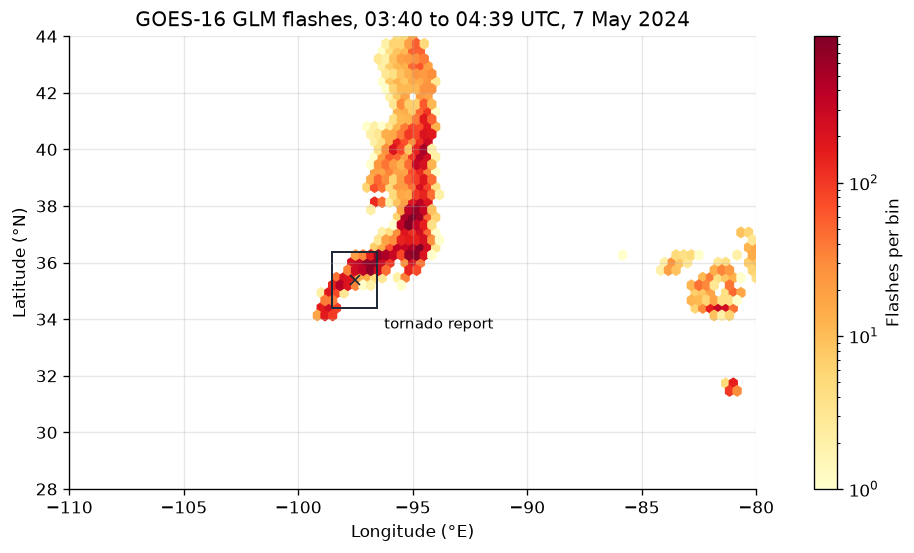

In [6]:
REPORT_UTC = pd.Timestamp("2024-05-07 04:39")
REPORT_LAT, REPORT_LON = 35.378, -97.543
HALF = 1.0
region = flashes[flashes.flash_lat.between(28, 44) & flashes.flash_lon.between(-110, -80)]
fig, ax = plt.subplots(layout="constrained")
bins = ax.hexbin(
    region.flash_lon,
    region.flash_lat,
    gridsize=(90, 30),
    bins="log",
    mincnt=1,
    cmap="YlOrRd",
    extent=(-110, -80, 28, 44),
)
ax.add_patch(
    Rectangle(
        (REPORT_LON - HALF, REPORT_LAT - HALF),
        2 * HALF,
        2 * HALF,
        fill=False,
        edgecolor="#1f2937",
        linewidth=1.2,
    )
)
ax.plot(REPORT_LON, REPORT_LAT, marker="x", color="#1f2937", markersize=6)
ax.annotate(
    "tornado report",
    (REPORT_LON + HALF, REPORT_LAT - HALF),
    xytext=(4, -12),
    textcoords="offset points",
    fontsize=9,
)
ax.set_aspect(1 / np.cos(np.radians(36)))
ax.set(
    xlim=(-110, -80),
    ylim=(28, 44),
    xlabel="Longitude (°E)",
    ylabel="Latitude (°N)",
    title="GOES-16 GLM flashes, 03:40 to 04:39 UTC, 7 May 2024",
)
fig.colorbar(bins, ax=ax, label="Flashes per bin")
plt.show()

In [7]:
north_south = flashes.flash_lat.between(REPORT_LAT - HALF, REPORT_LAT + HALF)
east_west = flashes.flash_lon.between(REPORT_LON - HALF, REPORT_LON + HALF)
storm = flashes[north_south & east_west]
cells = flashes.groupby(
    [
        np.floor((flashes.flash_lat - (REPORT_LAT - HALF)) / 2),
        np.floor((flashes.flash_lon - (REPORT_LON - HALF)) / 2),
    ]
).size()
rank = int((cells > cells.loc[(0.0, 0.0)]).sum()) + 1
print(f"Flashes in the box: {len(storm):,} of {len(flashes):,} ({len(storm) / len(flashes):.1%})")
print(f"The box ranks {rank} of {len(cells)} two-degree cells that hold any flash")
print(f"Busiest cell: {cells.max():,} flashes ({cells.max() / len(flashes):.1%})")

Flashes in the box: 5,314 of 48,315 (11.0%)
The box ranks 2 of 189 two-degree cells that hold any flash
Busiest cell: 8,871 flashes (18.4%)


One line of storms, from central Oklahoma north through eastern Kansas toward
Iowa, held nearly all the flashes in this view. The two-degree box around
the report holds about a tenth of every flash in a field of view that reaches
from Canada to Argentina, and only the cell just northeast of it holds more.
A flash centroid is an energy-weighted cloud-top position, not a ground
strike, and GLM's detection efficiency varies with viewing angle and cloud;
counts compare places and times within one instrument, not storm strength.

### Minute by minute

Binning on the decoded first-event time, the flashes inside the box per
minute, beside every flash in the field of view.

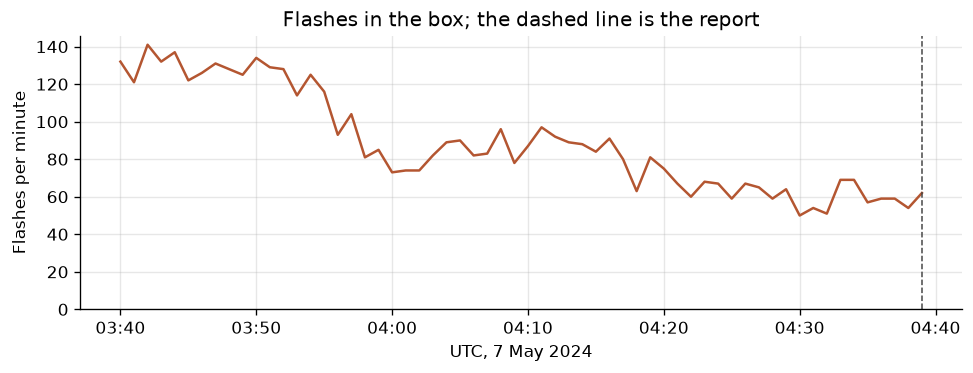

Box: 130 per minute in the first ten minutes, 58 in the last
Change: box -55%, whole field of view -15%
Flashes whose first event precedes the window: 10


In [8]:
window = pd.date_range("2024-05-07 03:40", "2024-05-07 04:39", freq="min")


def per_minute(frame: pd.DataFrame) -> pd.Series:
    """Flash counts for each whole minute of the window, zero-filled."""
    minute = frame.first_event_utc.dt.floor("min")
    return frame.groupby(minute).size().reindex(window, fill_value=0)


counts = pd.DataFrame({"box": per_minute(storm), "field_of_view": per_minute(flashes)})
fig, ax = plt.subplots(figsize=(8, 3), layout="constrained")
ax.plot(counts.index, counts.box, color="#b45631")
ax.axvline(REPORT_UTC, color="#444444", linewidth=0.9, linestyle="--")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set(
    ylim=(0, None),
    xlabel="UTC, 7 May 2024",
    ylabel="Flashes per minute",
    title="Flashes in the box; the dashed line is the report",
)
plt.show()
early, late = counts.head(10).mean(), counts.tail(10).mean()
change = 100 * (late - early) / early
print(f"Box: {early.box:.0f} per minute in the first ten minutes, {late.box:.0f} in the last")
print(f"Change: box {change.box:.0f}%, whole field of view {change.field_of_view:.0f}%")
print(
    "Flashes whose first event precedes the window:", len(flashes) - int(counts.field_of_view.sum())
)

Flashes in the box fell by about half over the hour while the whole field of
view fell by about a sixth: the storms near the report were producing fewer
flashes, not more, as the tornado was reported. That is one hour
of one case, with a fixed box that does not move with the storm; it says
nothing about how often a falling flash rate comes before a tornado.

## Pin and cite

`verify` checks every cached file against the lockfile's checksums. GLM files
are republished when NOAA reprocesses them, and a locked restore then fails
with a checksum mismatch; `usdata pull --update <id>` accepts one file's new
bytes and `--force` re-resolves the whole manifest. Keep the manifest and
lockfile with your analysis; the citation below is what a methods section
needs, and `usdata cite dataset.yaml` prints the same.

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

noaa:goes-glm
  NOAA Geostationary Operational Environmental Satellites (GOES) 16, 17, 18 & 19 was accessed on 2026-09-16 from https://registry.opendata.aws/noaa-goes
  homepage: https://registry.opendata.aws/noaa-goes/
  license: US Government Work (public domain)
  terms: https://www.noaa.gov/information-technology/open-data-dissemination
  retrieved: 2026-09-16; 180 checksummed assets (90,506,951 bytes) pinned by usdata 0.18.0
  sources: 1


## What was awkward

- The files cannot be cropped, so counting flashes in a two-degree box means
  downloading the whole field of view: about 90 MB for this active hour, 59 MB
  for a quiet afternoon hour, and roughly 1.4 GB a day.
- Positions and times are coordinates while energy and flags are data
  variables, and nothing in the file's layout says so. The obvious
  `reset_coords(drop=True)` deletes exactly the latitude, longitude, and time
  columns; `reset_coords()[columns]` is the spelling that works, and finding it
  took printing `sorted(ds.coords)`.
- The reader returns one Dataset per 20-second file, and combining them is
  left to every caller, so each notebook writes its own open, flatten, and
  concatenate loop. Decoding 180 files takes about as long as downloading them.
- A flash's first event can fall a fraction of a second before its file's
  nominal start, so a few flashes land before the window and a flash starting
  in the last fraction of the final minute sits in the next file, which this
  window does not request. Binning has to use the decoded times, not the file
  times.
- `flash_quality_flag` decodes as a float (0.0, 3.0, 5.0) rather than an
  integer code.

See the [GLM guide](https://docs.usdata.dev/providers/noaa-glm/) for the event,
group, and flash tables and the one-day window limit, and the
[tornado classification study](https://usdata.dev/studies/tornado-classification/)
for flashes joined to radar rotation around the same report.